In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 1. Wczytanie pliku i sprawdzenie pierwszych wierszy, by zorientować się w strukturze zbioru

df = pd.read_csv('HR_Analytics.csv', header=0)
print(df.head())

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

In [3]:
# 2. Podstawowa inspekcja
print(f"Rozmiar zbioru: {df.shape}")

print(f"\n")

#print(f"Typ kolumn:")
#print(df.dtypes)
#display(df.dtypes.to_frame(name='typ_danych'))

#print(f"\n")

print("Podstawowe informacje o kolumnach:")
print(df.info(verbose=True))

Rozmiar zbioru: (1470, 35)


Podstawowe informacje o kolumnach:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement

In [4]:
# 3. Braki danych

# Znajdowanie białych znaków i ich stripowanie
white_mask = df.map(lambda x: isinstance(x, str) and x.strip() == '')

# Znajdowanie wartości 'NaN'
nan_mask = df.isnull()

# Połączenie bitowe: 'white_mask' i 'nan_mask' czyli 'True' tam, gdzie wartość to 'NaN' lub białe znaki
missing_mask = nan_mask | white_mask

# Liczba pustych komórek w poszczególnych kolumnach
print(missing_mask.sum().to_frame(name='ile_pustych_wartości'))

# Procent pustych wartości w poszczególnych kolumnach
missing_precent = (missing_mask.sum()) / (len(df))
print(missing_precent.to_frame(name='%_pustych_wartości'))

                          ile_pustych_wartości
Age                                          0
Attrition                                    0
BusinessTravel                               0
DailyRate                                    0
Department                                   0
DistanceFromHome                             0
Education                                    0
EducationField                               0
EmployeeCount                                0
EmployeeNumber                               0
EnvironmentSatisfaction                      0
Gender                                       0
HourlyRate                                   0
JobInvolvement                               0
JobLevel                                     0
JobRole                                      0
JobSatisfaction                              0
MaritalStatus                                0
MonthlyIncome                                0
MonthlyRate                                  0
NumCompaniesW

In [5]:
# 4. Oczyszczanie danych
# Szukanie białych znaków i wartości NaN

# Znajdowanie białych znaków i ich stripowanie
white_mask = df.map(lambda x: isinstance(x, str) and x.strip() == '')

# Znajdowanie wartości 'NaN'
nan_mask = df.isnull()

# Połączenie bitowe: 'white_mask' i 'nan_mask' czyli 'True' tam, gdzie wartość to 'NaN' lub białe znaki
missing_mask = nan_mask | white_mask

# Liczba braków w kolumnach
missing_columns = missing_mask.sum()
missing_search = missing_columns.sum() > 0

if not missing_search:
    print("Brak pustych wartości w żadnej kolumnie — pomijam analizę wierszy")
else:
    print("Liczba brakujących wartości w kolumnach (w tym białe znaki):")
    
    # Pętla po kolumnach
    for col, count in missing_columns.items():
        if count > 0:
            print(f"Kolumna: [{col}] - pustych komórek: {count}")

    # Dodatkowa kolumna: wyrównanie wierszy z plikiem csv
    df['row_number'] = df.index + 2
    #print(df.index + 2)

    missing_rows = False

    len_empty_cell_rows = 0

    # Pętla po wierszach
    for idx, row in df.iterrows():
        missing_count = missing_mask.iloc[idx].sum()

        if missing_count > 0:
            missing_rows = True
            number = row['row_number']
            missing_value_column = missing_mask.iloc[idx][missing_mask.iloc[idx]].index.to_list()
            
            len_empty_cell_rows += 1

            print("-")
            print(f"Wiersz nr [{number}] - pustych komórek: {missing_count}")
            print(f"Brakujące wartości w kolumnach: {missing_value_column}")

    print(f"\n\nIlość wierszy z pustymi komórkami: {len_empty_cell_rows}")       

    
    # Co zrobić z wierszem, gdy mamy puste komórki
    if len_empty_cell_rows > 0:

        # Zamiana białych znaków na wartość 'NaN'
        df = df.replace(r'^\s*$', np.nan, regex=True)
        
        # Usunięcie pustych wierszy, które mają puste wartości
        df = df.dropna(how='any')

        # Ponowne sprawdzenie zbioru
        print("\nPo usunięciu wierszy zawierających puste komórki:")
        print(f"\nRozmiar zbioru: {df.shape}")

        print(f"\nPodstawowe informacje o kolumnach:\n{df.info(verbose=True)}")

Brak pustych wartości w żadnej kolumnie — pomijam analizę wierszy


In [6]:
# 5. Spójność kolumn typu 'object'

# Odczyt kolumn typu 'object'
columns_object = df.select_dtypes(include='object')
#display(columns_object)

# Utworzenie listy z kolumn 'object'
columns_list = columns_object.columns.to_list()
#print(columns_list)

# Przetworzenie kolumn czyli tworzenie ich spójności
for col in columns_list:
    df[col] = df[col].str.replace('_', ' ').str.strip().str.title()


print(df.select_dtypes(include='object'))

     Attrition     BusinessTravel              Department EducationField  \
0          Yes      Travel Rarely                   Sales  Life Sciences   
1           No  Travel Frequently  Research & Development  Life Sciences   
2          Yes      Travel Rarely  Research & Development          Other   
3           No  Travel Frequently  Research & Development  Life Sciences   
4           No      Travel Rarely  Research & Development        Medical   
...        ...                ...                     ...            ...   
1465        No  Travel Frequently  Research & Development        Medical   
1466        No      Travel Rarely  Research & Development        Medical   
1467        No      Travel Rarely  Research & Development  Life Sciences   
1468        No  Travel Frequently                   Sales        Medical   
1469        No      Travel Rarely  Research & Development        Medical   

      Gender                    JobRole MaritalStatus Over18 OverTime  
0     Female   

In [7]:
# 6. Analiza

# Podstawowe statystyki
workers_all = len(df)
print(f"Ilość pracowników: {workers_all}")

workers_no = (df['Attrition'] == 'No').sum()
print(f"Ilu zostało: {workers_no}")

workers_yes = (df['Attrition'] == 'Yes').sum()
print(f"Ilu odeszło: {workers_yes}")

#print(df['YearsSinceLastPromotion'].unique())
mean_yslp_all = round(df['YearsSinceLastPromotion'].mean(), 2)
print(f"Średnia lat od ostatniego awansu - wszyscy pracownicy: {mean_yslp_all}")

mean_yslp_no = round(df.loc[df['Attrition'] == 'No', 'YearsSinceLastPromotion'].mean(), 2)
print(f"Średnia lat od ostatniego awansu - zostali: {mean_yslp_no}")

mean_yslp_yes = round(df.loc[df['Attrition'] == 'Yes', 'YearsSinceLastPromotion'].mean(), 2)
print(f"Średnia lat od ostatniego awansu - odeszli: {mean_yslp_yes}")

#print(df['JobSatisfaction'].sort_values().unique())
mean_js_yes = round(df.loc[df['Attrition'] == 'Yes', 'JobSatisfaction'].mean(), 2)
print(f"Średnia satysfkacja z pracy (1-4) - odeszli: {mean_js_yes}")

#print(df['WorkLifeBalance'].sort_values().unique())
mean_wlb_yes = round(df.loc[df['Attrition'] == 'Yes', 'WorkLifeBalance'].mean(), 2)
print(f"Średnia równowaga między pracą, a życiem prywatnym (1-4) - odeszli: {mean_wlb_yes}")

without_promo = (df['YearsSinceLastPromotion'] > 5).sum()
print(f"Liczba pracowników bez awansu powyżej 5 lat: {without_promo}")

precent_without_promo = round((without_promo / workers_all * 100), 0)
print(f"Odsetek pracowników bez awansu powyżej 5 lat: {precent_without_promo} %")

Ilość pracowników: 1470
Ilu zostało: 1233
Ilu odeszło: 237
Średnia lat od ostatniego awansu - wszyscy pracownicy: 2.19
Średnia lat od ostatniego awansu - zostali: 2.23
Średnia lat od ostatniego awansu - odeszli: 1.95
Średnia satysfkacja z pracy (1-4) - odeszli: 2.47
Średnia równowaga między pracą, a życiem prywatnym (1-4) - odeszli: 2.66
Liczba pracowników bez awansu powyżej 5 lat: 215
Odsetek pracowników bez awansu powyżej 5 lat: 15.0 %


In [8]:
# Średnie statystyki dla osób, które odeszły a zostały, według różnych czynników

attrition_stats = df.groupby('Attrition')[['Age', 'MonthlyIncome', 'YearsAtCompany', 'YearsSinceLastPromotion']].mean().round(2)

print("\nŚrednie dla odchodzących vs. pozostających:\n", attrition_stats)


Średnie dla odchodzących vs. pozostających:
              Age  MonthlyIncome  YearsAtCompany  YearsSinceLastPromotion
Attrition                                                               
No         37.56        6832.74            7.37                     2.23
Yes        33.61        4787.09            5.13                     1.95


In [9]:
# Średnie nastroje w firmie

mood_cols = ['JobSatisfaction', 'EnvironmentSatisfaction', 'WorkLifeBalance', 'RelationshipSatisfaction']
moods = df[mood_cols].mean().round(2)

print("\nŚrednie nastroje w firmie (1-4):\n", moods)


Średnie nastroje w firmie (1-4):
 JobSatisfaction             2.73
EnvironmentSatisfaction     2.72
WorkLifeBalance             2.76
RelationshipSatisfaction    2.71
dtype: float64


In [10]:
# Średnie zadowolenie z pracy a kierunmkiem wykształcenia

education_satisfaction = df.groupby('EducationField')['JobSatisfaction'].mean().round(2).to_frame()

print("\nŚrednie JobSatisfaction wg EducationField:\n", education_satisfaction)


Średnie JobSatisfaction wg EducationField:
                   JobSatisfaction
EducationField                   
Human Resources              2.56
Life Sciences                2.80
Marketing                    2.65
Medical                      2.69
Other                        2.74
Technical Degree             2.66


In [11]:
# Średnie nastroje w działach

dept_moods = df.groupby('Department')[mood_cols].mean().round(2).sort_index()

print("\nŚrednie nastroje w działach (1-4):\n", dept_moods)


Średnie nastroje w działach (1-4):
                         JobSatisfaction  EnvironmentSatisfaction  \
Department                                                         
Human Resources                    2.60                     2.68   
Research & Development             2.73                     2.74   
Sales                              2.75                     2.68   

                        WorkLifeBalance  RelationshipSatisfaction  
Department                                                         
Human Resources                    2.92                      2.89  
Research & Development             2.73                      2.71  
Sales                              2.82                      2.70  


In [12]:
# Porównanie nastrojów między odchodzącymi a zostającymi

mood_attrition = df.groupby('Attrition')[mood_cols].mean().round(2)

print("\nNastroje: odejścia vs. zostali (1-4):\n", mood_attrition)


Nastroje: odejścia vs. zostali (1-4):
            JobSatisfaction  EnvironmentSatisfaction  WorkLifeBalance  \
Attrition                                                              
No                    2.78                     2.77             2.78   
Yes                   2.47                     2.46             2.66   

           RelationshipSatisfaction  
Attrition                            
No                             2.73  
Yes                            2.60  


In [13]:
# Przykładowi pracownicy do awansu

#print(df['YearsSinceLastPromotion'].sort_values().unique())
#print(df['PerformanceRating'].sort_values().unique())
#print(df['JobInvolvement'].sort_values().unique())

avg_pr = df.groupby('Attrition')['PerformanceRating'].mean().round(0)['No']
#print("Średnie PerformanceRating (Wydajność pracy): ", avg_pr)

avg_no = df.groupby('Attrition')['JobInvolvement'].mean().round(0)['No']
#print("Średnie JobInvolvement (Zaangażowanie)", avg_no)

yearsSinceLastPromotion = df['YearsSinceLastPromotion'] >= 5 # pracownicy, którzy nie mieli awansu przez 5 lat
performanceRating       = df['PerformanceRating'] >= avg_pr # pracownicy, których wydajność jest większa od średniej lub równa
jobInvolvement          = df['JobInvolvement'] > avg_no # pracownicy, których zaangażowanie jest większe od średniej
attritionNo             = df['Attrition'] == 'No' # pracownicy, którzy zostali w firmie

candidates_promotion = df[yearsSinceLastPromotion & performanceRating & jobInvolvement & attritionNo][['EmployeeNumber', 'JobRole', 'YearsSinceLastPromotion', 'PerformanceRating', 'JobInvolvement']].to_string(index=False)

print("\nPrzykładowi kandydaci do awansu:\n", candidates_promotion)


Przykładowi kandydaci do awansu:
  EmployeeNumber                   JobRole  YearsSinceLastPromotion  PerformanceRating  JobInvolvement
             20    Manufacturing Director                        8                  3               4
            381                   Manager                        6                  3               4
            382           Sales Executive                        7                  4               4
            416           Sales Executive                        7                  3               4
            474        Research Scientist                        6                  3               4
            532           Sales Executive                        7                  3               4
            621           Sales Executive                        5                  3               4
            653           Sales Executive                        5                  4               4
           1039           Sales Executive      

In [14]:
# Średnia i mediana dochodu wg płci

gender_income = df.groupby('Gender')['MonthlyIncome'].agg(['mean', 'median']).round(0).rename(columns={'mean': 'Średnia', 'median': 'Mediana'})

print("\nMediana dochodu wg płci:\n", gender_income)


Mediana dochodu wg płci:
         Średnia  Mediana
Gender                  
Female   6687.0   5082.0
Male     6381.0   4838.0


In [15]:
# Średnia i mediana dochodu w zależności od wykształcenia

education_income = df.groupby('EducationField')['MonthlyIncome'].agg(['mean', 'median']).round(0).rename(columns={'mean': 'Średnia', 'median': 'Mediana'})

print("\nRóżnice w dochodach a poziom wykształcenia:\n", education_income)


Różnice w dochodach a poziom wykształcenia:
                   Średnia  Mediana
EducationField                    
Human Resources    7241.0   3886.0
Life Sciences      6463.0   4943.0
Marketing          7349.0   6118.0
Medical            6510.0   4722.0
Other              6072.0   4561.0
Technical Degree   5758.0   4318.0


In [16]:
# Średnia i mediana dochodu od podróży służbowych

travel_income = df.groupby('BusinessTravel')['MonthlyIncome'].agg(['mean', 'median']).round(0).rename(columns={'mean': 'Średnia', 'median': 'Mediana'})

print("\nŚrednia i mediana dochodu wg podróży służbowych:\n", travel_income)


Średnia i mediana dochodu wg podróży służbowych:
                    Średnia  Mediana
BusinessTravel                     
Non-Travel          6262.0   4974.0
Travel Frequently   6194.0   4735.0
Travel Rarely       6620.0   4960.0


In [17]:
# Tabela przestawna: Średnia i medaiana dochodu wg podróży a odejścia

pivot_travel_income_attrition = pd.pivot_table(df, index='BusinessTravel', columns='Attrition', values='MonthlyIncome', aggfunc=['mean', 'median']).round(0).rename(columns={'mean': 'Średnia', 'median': 'Mediana'})

print("\nŚrednia i mediana wypłat wg podróży a odejścia:\n", pivot_travel_income_attrition)


Średnia i mediana wypłat wg podróży a odejścia:
                   Średnia         Mediana        
Attrition              No     Yes      No     Yes
BusinessTravel                                   
Non-Travel         6351.0  5241.0  5086.0  4176.0
Travel Frequently  6828.0  4281.0  5112.0  2909.0
Travel Rarely      6909.0  4976.0  5228.0  3408.0


In [18]:
# Mediana lat bez awansu wg płci
#print(df['YearsSinceLastPromotion'].unique())

gender_promo = df.groupby('Gender')['YearsSinceLastPromotion'].median().round(0).to_frame()

print("\nMediana lat bez awansu wg płci:\n", gender_promo)


Mediana lat bez awansu wg płci:
         YearsSinceLastPromotion
Gender                         
Female                      1.0
Male                        1.0


In [19]:
# Odsetek odejść z firmy wg płci

gender_attrition = df.groupby(['Gender', 'Attrition']).size().unstack(fill_value=0)
gender_attrition['AttritionPrecent'] = (gender_attrition['Yes'] / gender_attrition.sum(axis=1) * 100).round(0).astype(str) + ' %'

print("\nOdejścia wg płci:\n", gender_attrition)
#print(type('AttritionPrecent'))


Odejścia wg płci:
 Attrition   No  Yes AttritionPrecent
Gender                              
Female     501   87           15.0 %
Male       732  150           17.0 %


In [20]:
# Odsetek odejść wg wyjazdów służbowych
#print(df['BusinessTravel'].unique())

travel_attrition = df.groupby(['BusinessTravel', 'Attrition']).size().unstack(fill_value=0)
travel_attrition['AttritionPrecent'] = (travel_attrition['Yes'] / travel_attrition.sum(axis=1) * 100).round(0).astype(str) + ' %'

print("\nOdejścia wg wyjazdów służbowych:\n", travel_attrition)


Odejścia wg wyjazdów służbowych:
 Attrition           No  Yes AttritionPrecent
BusinessTravel                              
Non-Travel         138   12            8.0 %
Travel Frequently  208   69           25.0 %
Travel Rarely      887  156           15.0 %


In [21]:
# Średnia nastroje z pracy wg stanu cywilnego

marital_satisfaction = df.groupby('MaritalStatus')['JobSatisfaction'].mean().round(2).to_frame()

print("Średnie satysfkacja z pracy wg stanu cywilnego (1-4):\n", marital_satisfaction)

Średnie satysfkacja z pracy wg stanu cywilnego (1-4):
                JobSatisfaction
MaritalStatus                 
Divorced                  2.70
Married                   2.72
Single                    2.77


In [22]:
# Odsetek odejść wg stanu cywilnego

marital_attrition = df.groupby(['MaritalStatus', 'Attrition']).size().unstack(fill_value=0)
marital_attrition['AttritionPrecent'] = (marital_attrition['Yes'] / marital_attrition.sum(axis=1) * 100).round(0).astype(str) + ' %'

print("\nOdejścia wg stanu cywilnego:\n", marital_attrition)


Odejścia wg stanu cywilnego:
 Attrition       No  Yes AttritionPrecent
MaritalStatus                           
Divorced       294   33           10.0 %
Married        589   84           12.0 %
Single         350  120           26.0 %


In [23]:
# Odsetek odejść wg działów i stanowisk

#print(df['Department'].unique())
#print(df['JobRole'].unique())
#dept_attrition = df.groupby(['Department', 'Attrition']).size()
#print(dept_attrition)

dept_role_attrition = df.groupby(['Department', 'JobRole', 'Attrition']).size().unstack(fill_value=0)
dept_role_attrition['AttritionPercent'] = (dept_role_attrition['Yes'] / dept_role_attrition.sum(axis=1) * 100).round(0).astype(str) + ' %'
#dept_role_attrition = dept_role_attrition[['Yes', 'AttritionPercent']]

print("\nOdejścia wg stanowisk w działach:\n", dept_role_attrition)


Odejścia wg stanowisk w działach:
 Attrition                                          No  Yes AttritionPercent
Department             JobRole                                             
Human Resources        Human Resources             40   12           23.0 %
                       Manager                     11    0            0.0 %
Research & Development Healthcare Representative  122    9            7.0 %
                       Laboratory Technician      197   62           24.0 %
                       Manager                     51    3            6.0 %
                       Manufacturing Director     135   10            7.0 %
                       Research Director           78    2            2.0 %
                       Research Scientist         245   47           16.0 %
Sales                  Manager                     35    2            5.0 %
                       Sales Executive            269   57           17.0 %
                       Sales Representative        5

In [24]:
# Odsetek odejść wg działów

dept_attrition = df.groupby(['Department', 'Attrition']).size().unstack(fill_value=0)
dept_attrition['AttritionPrecent'] = ((dept_attrition['Yes'] / dept_attrition.sum(axis=1)) * 100).round(0).astype(str) + ' %'

print("\nOdejścia wg działu:\n", dept_attrition)


Odejścia wg działu:
 Attrition                No  Yes AttritionPrecent
Department                                       
Human Resources          51   12           19.0 %
Research & Development  828  133           14.0 %
Sales                   354   92           21.0 %


In [25]:
# Odsetek odejść wg stanowisk

#print(df['JobRole'].unique())

role_attrition = df.groupby(['JobRole', 'Attrition']).size().unstack(fill_value=0)
role_attrition['AttritionPrecent'] = ((role_attrition['Yes'] / role_attrition.sum(axis=1)) * 100).round(0).astype(str) + ' %'

print("\nOdejścia wg stanowisk:\n", role_attrition)


Odejścia wg stanowisk:
 Attrition                   No  Yes AttritionPrecent
JobRole                                             
Healthcare Representative  122    9            7.0 %
Human Resources             40   12           23.0 %
Laboratory Technician      197   62           24.0 %
Manager                     97    5            5.0 %
Manufacturing Director     135   10            7.0 %
Research Director           78    2            2.0 %
Research Scientist         245   47           16.0 %
Sales Executive            269   57           17.0 %
Sales Representative        50   33           40.0 %


In [26]:
# Odsetek odejść wg podziału lat bez braku awansu (przedział lat)

promo_bins = pd.cut(df['YearsSinceLastPromotion'], bins=[0, 1, 3, 5, 7, 9, 20], labels=['<=1', '1-3', '3-5', '5-7', '7-9', '>9'])
promo_attrition = df.groupby([promo_bins, 'Attrition'], observed=False).size().unstack(fill_value=0)
promo_attrition['AttritionPrecent'] = ((promo_attrition['Yes'] / promo_attrition.sum(axis=1)) * 100).round(0).astype(str) + ' %'

print("\nOdejścia w zależności od lat, bez braku awansu:\n", promo_attrition)


Odejścia w zależności od lat, bez braku awansu:
 Attrition                 No  Yes AttritionPrecent
YearsSinceLastPromotion                           
<=1                      308   49           14.0 %
1-3                      175   36           17.0 %
3-5                       99    7            7.0 %
5-7                       86   22           20.0 %
7-9                       31    4           11.0 %
>9                        63    9           12.0 %


In [27]:
# Odsetek odejść a nastroje

#print(df['JobSatisfaction'].sort_values().unique())
#print(df['EnvironmentSatisfaction'].sort_values().unique())
#print(df['WorkLifeBalance'].sort_values().unique())
#print(df['RelationshipSatisfaction'].sort_values().unique())

satisfaction_cols = ['JobSatisfaction', 'EnvironmentSatisfaction', 'WorkLifeBalance', 'RelationshipSatisfaction']

for col in satisfaction_cols:
    sat_attrition = df.groupby([col, 'Attrition']).size().unstack(fill_value=0)
    sat_attrition['AttritionPrecent'] = ((sat_attrition['Yes'] / sat_attrition.sum(axis=1)) * 100).round(0).astype(str) + ' %'
    
    print(f"\nOdejścia wg {col}:\n", sat_attrition)


Odejścia wg JobSatisfaction:
 Attrition         No  Yes AttritionPrecent
JobSatisfaction                           
1                223   66           23.0 %
2                234   46           16.0 %
3                369   73           17.0 %
4                407   52           11.0 %

Odejścia wg EnvironmentSatisfaction:
 Attrition                 No  Yes AttritionPrecent
EnvironmentSatisfaction                           
1                        212   72           25.0 %
2                        244   43           15.0 %
3                        391   62           14.0 %
4                        386   60           13.0 %

Odejścia wg WorkLifeBalance:
 Attrition         No  Yes AttritionPrecent
WorkLifeBalance                           
1                 55   25           31.0 %
2                286   58           17.0 %
3                766  127           14.0 %
4                126   27           18.0 %

Odejścia wg RelationshipSatisfaction:
 Attrition                  No  Yes At

In [28]:
# Odsetek odejść a nadgodziny

#print(df['OverTime'].unique())

overtime_attrition = df.groupby(['OverTime', 'Attrition']).size().unstack(fill_value=0)
overtime_attrition['AttritionPrecent'] = ((overtime_attrition['Yes'] / overtime_attrition.sum(axis=1)) * 100).round(0).astype(str) + ' %'

print("\nOdejścia a nadgodziny:\n", overtime_attrition)


Odejścia a nadgodziny:
 Attrition   No  Yes AttritionPrecent
OverTime                            
No         944  110           10.0 %
Yes        289  127           31.0 %


In [29]:
# Odsetek odejść wg podziału dochodów na kwantyle (poziom dochodów)

#print(df['MonthlyIncome'].unique())

income_bins = pd.qcut(df['MonthlyIncome'], q=4, labels=['Niskie', 'Średnie', 'Wysokie', 'Bardzo Wysokie'])
income_attrition = df.groupby([income_bins, 'Attrition'], observed=False).size().unstack(fill_value=0)
income_attrition['AttritionPrecent'] = ((income_attrition['Yes'] / income_attrition.sum(axis=1)) * 100).round(0).astype(str) + ' %'

print("\nOdejścia wg poziomu dochodów:\n", income_attrition)


Odejścia wg poziomu dochodów:
 Attrition        No  Yes AttritionPrecent
MonthlyIncome                            
Niskie          261  108           29.0 %
Średnie         314   52           14.0 %
Wysokie         328   39           11.0 %
Bardzo Wysokie  330   38           10.0 %


In [30]:
# Odsetek odejść wg podziału stażu w firmie (przedział lat)

cadence_cut = pd.cut(df['YearsAtCompany'], bins=[0, 2, 5, 10, 20, 40], labels=['0-2', '3-5', '6-10', '11-20', '20+'])
cadence_attrition = df.groupby([cadence_cut,'Attrition'], observed=False).size().unstack(fill_value=0)
cadence_attrition['AttritionPrecent'] = ((cadence_attrition['Yes'] / cadence_attrition.sum(axis=1)) * 100).round(0).astype(str) + ' %'

print("\nOdejścia wg stażu w firmie:\n", cadence_attrition)


Odejścia wg stażu w firmie:
 Attrition        No  Yes AttritionPrecent
YearsAtCompany                           
0-2             212   86           29.0 %
3-5             374   60           14.0 %
6-10            393   55           12.0 %
11-20           168   12            7.0 %
20+              58    8           12.0 %


In [31]:
# Odsetek odejść wg podziału dochdu oraz nadgodziny

income_median = df['MonthlyIncome'].median()
df['IncomeLevel'] = np.where(df['MonthlyIncome'] <= income_median, 'Niski', 'Wysoki')
income_overtime_attrition = df.groupby(['IncomeLevel', 'OverTime', 'Attrition'], observed=False).size().unstack(fill_value=0)
income_overtime_attrition['AttritionPercent'] = ((income_overtime_attrition['Yes'] / income_overtime_attrition.sum(axis=1)) * 100).round(0).astype(str) + ' %'

print("\nOdejścia wg dochodów i nadgodzin:\n", income_overtime_attrition)


Odejścia wg dochodów i nadgodzin:
 Attrition              No  Yes AttritionPercent
IncomeLevel OverTime                           
Niski       No        460   73           14.0 %
            Yes       115   87           43.0 %
Wysoki      No        484   37            7.0 %
            Yes       174   40           19.0 %


In [32]:
# Odsetek odejść wg podziału dochodów na kwantyle i różnych kombinacji czynników

income_qcut = pd.qcut(df['MonthlyIncome'], q=4, labels=['Niskie', 'Średnie', 'Wysokie', 'Bardzo Wysokie'])
df['SatisfactionLevel'] = np.where(df['JobSatisfaction'] <= 2, 'Niska', 'Wysoka')

combination_attrition = df.groupby([income_qcut, 'OverTime', 'SatisfactionLevel', 'Attrition'], observed=False).size().unstack(fill_value=0)
combination_attrition['AttritionPercent'] = ((combination_attrition['Yes'] / combination_attrition.sum(axis=1)) * 100).round(0).astype(str) + ' %'

print("\nAnaliza odejść wg różnych czynników:\n", combination_attrition)


Analiza odejść wg różnych czynników:
 Attrition                                   No  Yes AttritionPercent
MonthlyIncome  OverTime SatisfactionLevel                           
Niskie         No       Niska               78   22           22.0 %
                        Wysoka             139   24           15.0 %
               Yes      Niska               15   29           66.0 %
                        Wysoka              29   33           53.0 %
Średnie        No       Niska               90   17           16.0 %
                        Wysoka             153   10            6.0 %
               Yes      Niska               26    8           24.0 %
                        Wysoka              45   17           27.0 %
Wysokie        No       Niska               94   11           10.0 %
                        Wysoka             146    7            5.0 %
               Yes      Niska               27    4           13.0 %
                        Wysoka              61   17           22

In [33]:
# Tabela przestawna: nadgodziny + poziom nastroju pracy a poziom dochodów

income_median = df['MonthlyIncome'].median()
df['IncomeLevel'] = np.where(df['MonthlyIncome'] <= income_median, 'Niski', 'Wysoki')
df['SatisfactionLevel'] = np.where(df['JobSatisfaction'] <= 2, 'Niska', 'Wysoka')
pivot_counts = pd.pivot_table(df[df['Attrition'] == 'Yes'], index=['OverTime', 'SatisfactionLevel'], columns='IncomeLevel', values='EmployeeNumber', aggfunc='count', fill_value=0)

print("\nTabela przestawna — nadgodziny + nastrój w pracy a dochód:\n", pivot_counts)


Tabela przestawna — nadgodziny + nastrój w pracy a dochód:
 IncomeLevel                 Niski  Wysoki
OverTime SatisfactionLevel               
No       Niska                 39      17
         Wysoka                34      20
Yes      Niska                 37      19
         Wysoka                50      21


In [34]:
# Odsetek odejść wg podróży służbowych a przedziały dochodu

income_qcut = pd.qcut(df['MonthlyIncome'], q=4, labels=['Niskie', 'Średnie', 'Wysokie', 'Bardzo Wysokie'])
business_attrition = df.groupby(['BusinessTravel', income_qcut, 'Attrition'], observed=False).size().unstack(fill_value=0)
business_attrition['AttritionPercent'] = ((business_attrition['Yes'] / business_attrition.sum(axis=1)) * 100).round(0).astype(str) + ' %'

print("\nOdsetek odejść wg podróży służbowych a przedziały dochodu:\n", business_attrition)


Odsetek odejść wg podróży służbowych a przedziały dochodu:
 Attrition                          No  Yes AttritionPercent
BusinessTravel    MonthlyIncome                            
Non-Travel        Niskie           30    5           14.0 %
                  Średnie          37    2            5.0 %
                  Wysokie          40    2            5.0 %
                  Bardzo Wysokie   31    3            9.0 %
Travel Frequently Niskie           39   35           47.0 %
                  Średnie          55   16           23.0 %
                  Wysokie          53   10           16.0 %
                  Bardzo Wysokie   61    8           12.0 %
Travel Rarely     Niskie          192   68           26.0 %
                  Średnie         222   34           13.0 %
                  Wysokie         235   27           10.0 %
                  Bardzo Wysokie  238   27           10.0 %


In [35]:
# Tabela przestawna: Odsetek odejść wg podziału dochodów i częstotliwości podróży służbowych

df['AttritionFlag'] = df['Attrition'].map({'Yes': 1, 'No': 0})
pivot_bt_income = pd.pivot_table(df, index='BusinessTravel', columns=income_qcut, values='AttritionFlag', aggfunc='mean', observed=False).mul(100).round(0).astype(str) + ' %'

print("\nOdsetek odejść wg częstotliwości podróży służbowych i przedziałów dochodów:\n", pivot_bt_income)


Odsetek odejść wg częstotliwości podróży służbowych i przedziałów dochodów:
 MonthlyIncome      Niskie Średnie Wysokie Bardzo Wysokie
BusinessTravel                                          
Non-Travel         14.0 %   5.0 %   5.0 %          9.0 %
Travel Frequently  47.0 %  23.0 %  16.0 %         12.0 %
Travel Rarely      26.0 %  13.0 %  10.0 %         10.0 %


In [36]:
# Odsetek ryzyka odejść wg 5 lat bez awansu
#print(df['YearsSinceLastPromotion'].sort_values().unique())

df['LeftGroup'] = np.where(df['YearsSinceLastPromotion'] >= 5, 'Odchodzący', 'OK')
left_attrition = df.groupby(['LeftGroup', 'Attrition']).size().unstack(fill_value=0)
left_attrition['AttritionPrecent'] = ((left_attrition['Yes'] / left_attrition.sum(axis=1)) * 100).round(0).astype(str) + ' %'

print("\nPracownicy odchodzący, powyżej 5-ciu lat bez awansu:\n", left_attrition)


Pracownicy odchodzący, powyżej 5-ciu lat bez awansu:
 Attrition     No  Yes AttritionPrecent
LeftGroup                             
OK          1010  200           17.0 %
Odchodzący   223   37           14.0 %


In [37]:
# Tabela przestwana: Grupa odchodzących wg działu

pivot_left_dept = pd.pivot_table(df, index='Department', columns='LeftGroup', values='EmployeeNumber', aggfunc='count', fill_value=0)

print("\nTabela przestawna (Dział x Odchodzący):\n", pivot_left_dept)


Tabela przestawna (Dział x Odchodzący):
 LeftGroup                OK  Odchodzący
Department                             
Human Resources          55           8
Research & Development  801         160
Sales                   354          92


In [38]:
# Korelacje z atrybutem Attrition

df['AttritionFlag'] = df['Attrition'].map({'Yes': 1, 'No': 0})
correlations = df.corr(numeric_only=True)['AttritionFlag'].abs().sort_values(ascending=False).head(10).round(2).to_frame()

print("\nKorelacje z odejściami:\n", correlations)


Korelacje z odejściami:
                       AttritionFlag
AttritionFlag                  1.00
TotalWorkingYears              0.17
JobLevel                       0.17
YearsInCurrentRole             0.16
MonthlyIncome                  0.16
Age                            0.16
YearsWithCurrManager           0.16
StockOptionLevel               0.14
YearsAtCompany                 0.13
JobInvolvement                 0.13


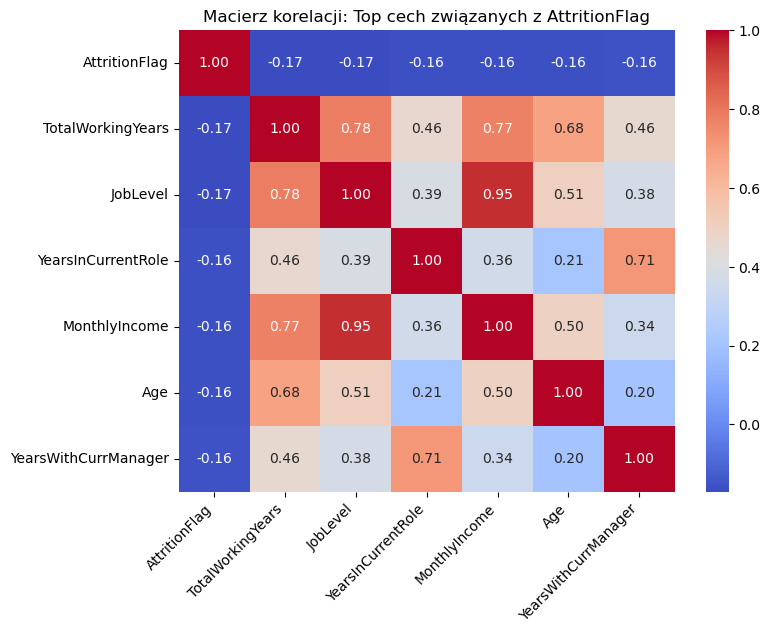

In [39]:
# 7. Wizualizacje

# Korelacja AttritionFlag

corr_matrix = df.corr(numeric_only=True)

top_cols = corr_matrix['AttritionFlag'].abs().sort_values(ascending=False).head(7).index

#top_cols = ["AttritionFlag","Age","MonthlyIncome","YearsAtCompany",
#            "YearsSinceLastPromotion","JobSatisfaction","EnvironmentSatisfaction",
#            "WorkLifeBalance","JobInvolvement","PerformanceRating",
#            "DistanceFromHome","NumCompaniesWorked","TotalWorkingYears"]

top_corr = corr_matrix.loc[top_cols, top_cols]
#print(top_corr)

plt.figure(figsize=(8, 6))
ax = sns.heatmap(top_corr, annot=True, fmt='.2f', cmap='coolwarm', cbar=True)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right') 
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.title("Macierz korelacji: Top cech związanych z AttritionFlag")

plt.show()

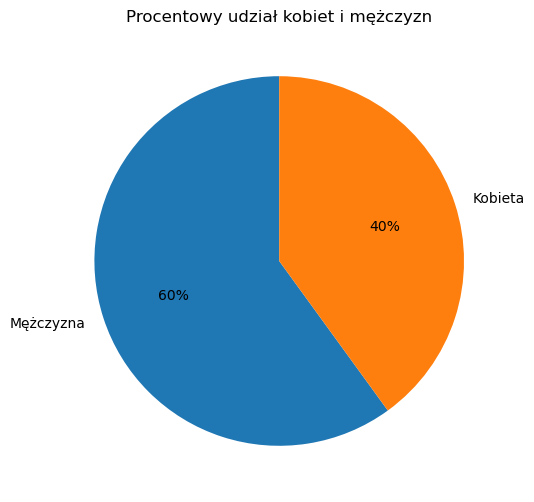

In [40]:
# Pie: Female vs Male

# Procentowy udział kobiet i mężczyzn w firmie
gender_precent = df['Gender'].value_counts(normalize=True).mul(100)
#print(df['Gender'].unique())
#print(gender_precent.index)

gender = gender_precent.index.to_series().map({'Female': 'Kobieta', 'Male': 'Mężczyzna'})

plt.figure(figsize=(8, 6))

plt.pie(x=gender_precent, labels=gender, autopct='%1.0f%%', startangle=90)
plt.title("Procentowy udział kobiet i mężczyzn")

plt.show()

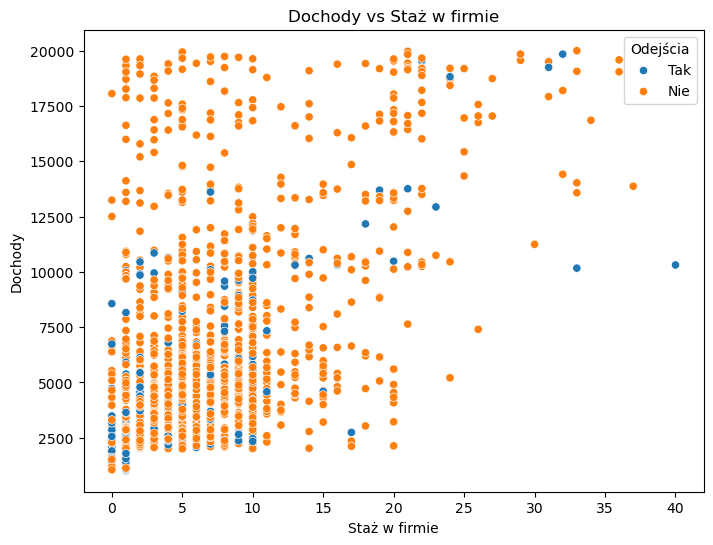

In [41]:
# Scatter: YearsAtCompany vs MonthlyIncome

df['Odejścia'] = df['Attrition'].map({'Yes': 'Tak', 'No': 'Nie'})

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='YearsAtCompany', y='MonthlyIncome', hue='Odejścia')

plt.title("Dochody vs Staż w firmie")
plt.xlabel("Staż w firmie")
plt.ylabel("Dochody")

plt.show()

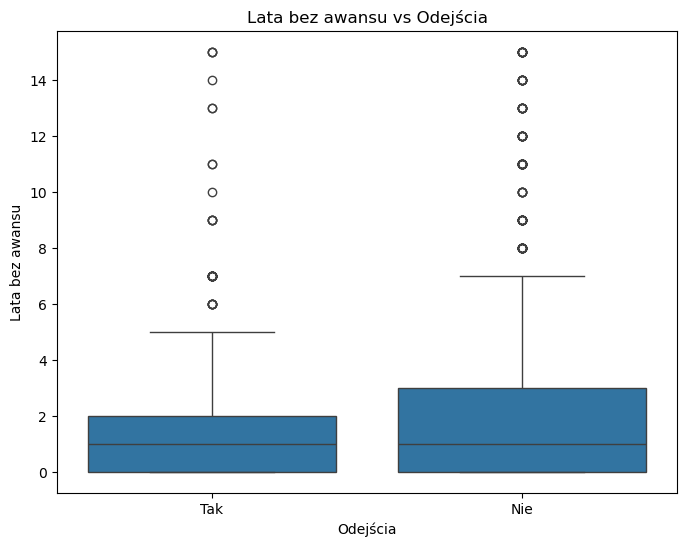

In [42]:
# Boxplot: YearsSinceLastPromotion vs Attrition

df['AttritionLabel'] = df['Attrition'].map({'Yes': 'Tak', 'No': 'Nie'})

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='AttritionLabel', y='YearsSinceLastPromotion')

plt.title("Lata bez awansu vs Odejścia")
plt.xlabel("Odejścia")
plt.ylabel("Lata bez awansu")

plt.show()

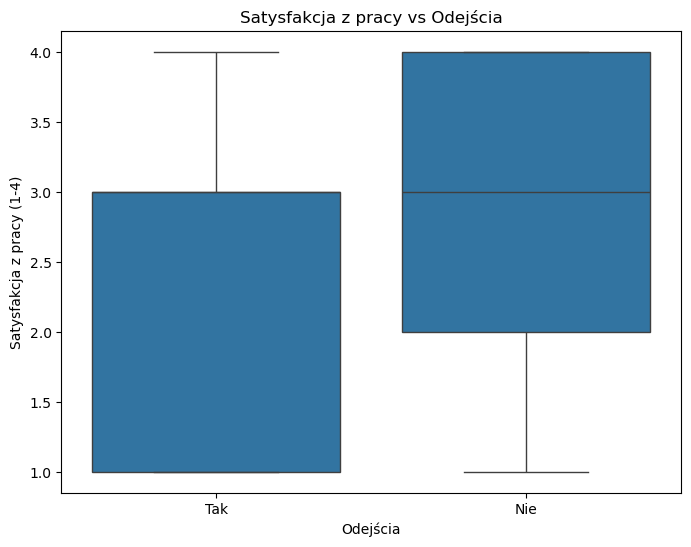

In [43]:
# Boxplot: JobSatisfaction vs Attrition

df['AttritionLabel'] = df['Attrition'].map({'Yes': 'Tak', 'No': 'Nie'})

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='AttritionLabel', y='JobSatisfaction')

plt.title("Satysfakcja z pracy vs Odejścia")
plt.xlabel("Odejścia")
plt.ylabel("Satysfakcja z pracy (1-4)")

plt.show()

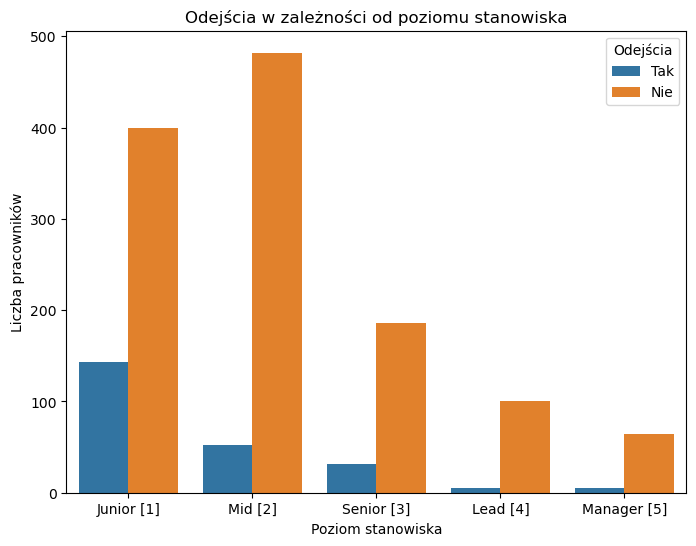

In [44]:
# Countplot: Attrition by JobLevel

df['Odejścia'] = df['Attrition'].map({'Yes': 'Tak', 'No': 'Nie'})

# Własne etykiety
joblevel_labels = {
    1: 'Junior [1]',
    2: 'Mid [2]',
    3: 'Senior [3]',
    4: 'Lead [4]',
    5: 'Manager [5]'
}
df['JobLevelLabel'] = df['JobLevel'].map(joblevel_labels)

# Lista w kolejności po kluczach 
joblevel_order = [joblevel_labels[i] for i in sorted(joblevel_labels.keys())]


plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='JobLevelLabel', hue='Odejścia', order=joblevel_order)

plt.title("Odejścia w zależności od poziomu stanowiska")
plt.xlabel("Poziom stanowiska")
plt.ylabel("Liczba pracowników")

plt.show()

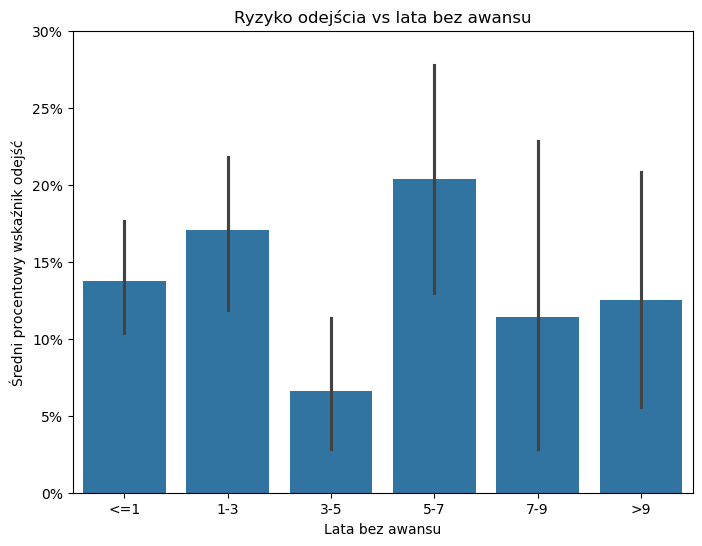

In [45]:
# Barplot: Attrition by YearsSinceLastPromotion

promo_bins = pd.cut(df['YearsSinceLastPromotion'], bins=[0, 1, 3, 5, 7, 9, 20], labels=['<=1', '1-3', '3-5', '5-7', '7-9', '>9'])

df['AttritionFlag'] = df['Attrition'].map({'Yes': 1, 'No': 0})

plt.figure(figsize=(8, 6))
ax = sns.barplot(data=df, x=promo_bins, y='AttritionFlag')

y_ticks = ax.get_yticks()
ax.set_yticks(y_ticks)
ax.set_yticklabels([f"{int(y*100)}%" for y in y_ticks])

plt.title("Ryzyko odejścia vs lata bez awansu")
plt.xlabel("Lata bez awansu")
plt.ylabel("Średni procentowy wskaźnik odejść")

plt.show()

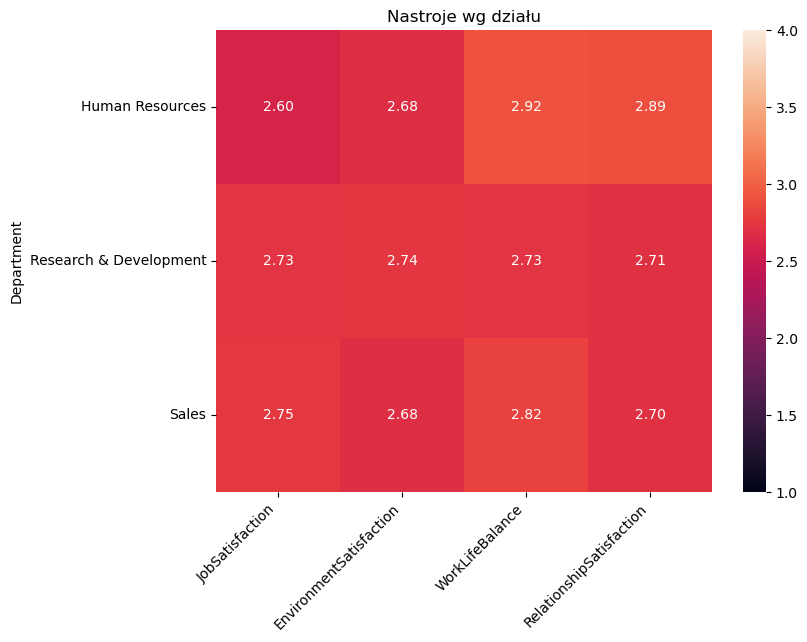

In [46]:
# Heatmap: Stisfactions vs Department
mood_cols = ['JobSatisfaction', 'EnvironmentSatisfaction', 'WorkLifeBalance', 'RelationshipSatisfaction']
dept_mean = df.groupby('Department')[mood_cols].mean().round(2)

plt.figure(figsize=(8, 6))
ax = sns.heatmap(data=dept_mean, fmt='.2f', annot=True, cbar=True, vmin=1, vmax=4)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right') 
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.title("Nastroje wg działu");

plt.show()

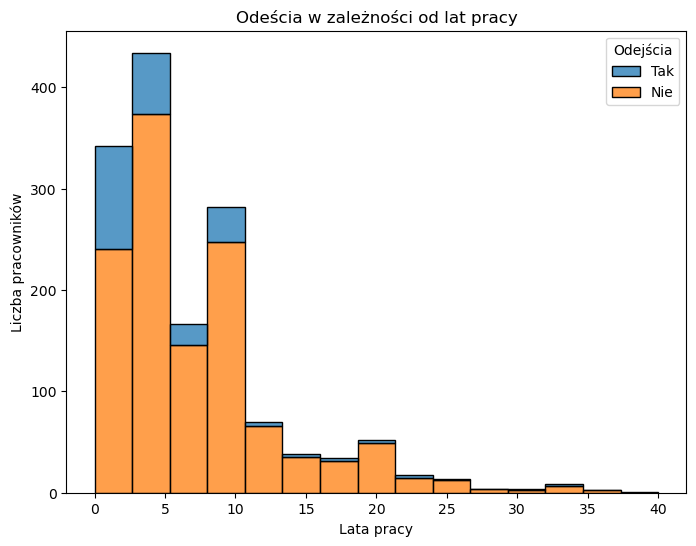

In [47]:
# Histplot: YearsAtCompany vs Attrition

df['Odejścia'] = df['Attrition'].map({'Yes': 'Tak', 'No': 'Nie'})

plt.figure(figsize=(8, 6))

sns.histplot(data=df, x='YearsAtCompany', hue='Odejścia', multiple='stack', bins=15)
plt.title("Odeścia w zależności od lat pracy")

plt.xlabel("Lata pracy")
plt.ylabel("Liczba pracowników")

plt.show()

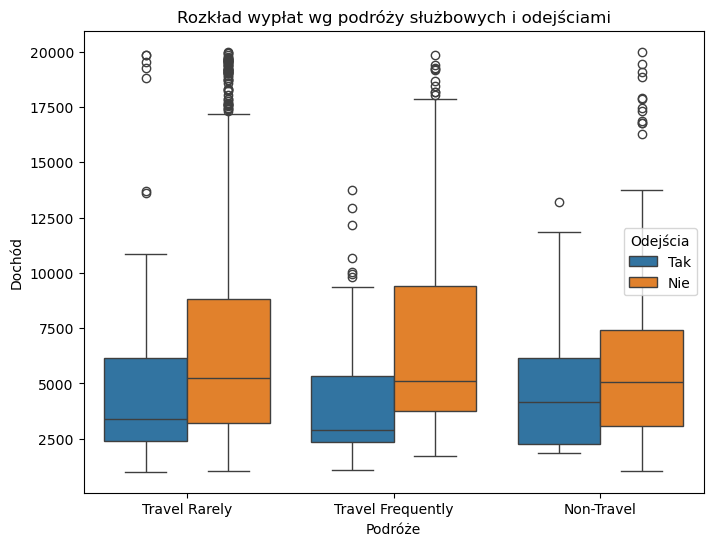

In [48]:
# Boxplot: BusinessTravel x MonthlyIncome vs Attrition

df['Odejścia'] = df['Attrition'].map({'Yes': 'Tak', 'No': 'Nie'})

plt.figure(figsize=(8, 6))

sns.boxplot(data=df, x='BusinessTravel', y='MonthlyIncome', hue='Odejścia')

plt.title("Rozkład wypłat wg podróży służbowych i odejściami")
plt.xlabel("Podróże")
plt.ylabel("Dochód")

plt.show()

In [49]:
# Zapis czystego pliku

file = 'HP_Analitycs_cleaned.csv'
df.to_csv(file, index=False, encoding='utf-8-sig')

print(f"Dane zapisano do pliku: {file}")

Dane zapisano do pliku: HP_Analitycs_cleaned.csv


Wnioski:
- Na podstawie przeprowadzonej analizy wyników, wykresów oraz korelacji można stwierdzić, że ryzyko odejścia pracownika należy analizować przez połączenie kilku czynników jednocześnie.

- Największe ryzyko odejścia dotyczy przede wszystkim pracowników z krótszym stażem w firmie, niższym poziomem stanowiska, niższymi dochodami oraz niższą satysfakcją z pracy. Wykresy pokazują, że osoby odchodzące częściej znajdują się na niższych stanowiskach, mają krótszy czas pracy w firmie oraz zwykle niższe wynagrodzenia. Dodatkowo niższa satysfakcja z pracy i gorsza ocena środowiska pracy również mogą zwiększać prawdopodobieństwo odejścia.

- Analiza pokazuje także, że ważne znaczenie mają nadgodziny oraz podróże służbowe. Pracownicy pracujący w nadgodzinach odchodzą częściej niż osoby bez nadgodzin, a częste podróże służbowe w połączeniu z niższym wynagrodzeniem dodatkowo zwiększają ryzyko odejścia.

- Wyniki wskazują również, że brak awansu nie jest samodzielnie najważniejszym czynnikiem odejścia. Może on jednak mieć znaczenie w połączeniu z innymi czynnikami, takimi jak niska satysfakcja, niskie wynagrodzenie lub brak dalszych perspektyw rozwoju.

- Ogólnie można stwierdzić, że firma powinna skupić się przede wszystkim na ograniczeniu nadgodzin, poprawie wynagrodzeń w najbardziej zagrożonych grupach, lepszym wsparciu nowych pracowników oraz monitorowaniu satysfakcji z pracy. Szczególną uwagę warto zwrócić na działy i stanowiska o najwyższej rotacji, zwłaszcza Sales Representative, Laboratory Technician oraz Human Resources.